In [1]:
import os
import sys
import numpy as np
import swyft
import pickle
import matplotlib.pyplot as plt
import torch
import importlib
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import LearningRateMonitor
torch.set_float32_matmul_precision('medium')
device_notebook = "cuda" if torch.cuda.is_available() else "cpu"
import wandb
import copy
from torch.multiprocessing import Pool
torch.multiprocessing.set_start_method('spawn',force=True)
torch.set_num_threads(28)
import itertools
import subprocess
from tqdm.auto import tqdm
sys.path.append('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')
from explim_functions import generate_expected_limits
from scipy.integrate import trapz

In [2]:
main_dir = "ALPs_with_SWYFT"
thesis_figs = os.getcwd().split(main_dir)[0]+"/"+main_dir+"/thesis_figures/"

In [3]:
names = ['flare0_agnostic', 'flare0_semi_informed', 'flare0_informed','flare0_confident1','flare0_confident3']
titles = ["Agnostic Prior", "Semi-Informed Prior", "Informed Prior", "Confident Prior", "CTAO Prior'"]
xlabel = "ALP mass ($m_\mathrm{a}$) / $\mathrm{neV}$"
ylabel = "Photon-ALP coupling ($g_{\mathrm{a}\gamma}$) / $10^{-11} \mathrm{GeV}^{-1}$"
colors_priors = ['r','#FFA500','y','g','b', ]

In [11]:
priors = {}
for ip, name in enumerate(names):

    priors[name] = {'name': name}

    priors[name]['results_path'] = '/home/gertwk/ALPs_with_SWYFT/cluster_runs/analysis_results/'+name

    priors[name]['store_path'] = priors[name]['results_path']+"/sim_output/store"

    priors[name]['config_vars'] = priors[name]['results_path'] +'/config_variables.pickle'

    priors[name]['config_phys'] = priors[name]['results_path'] +'/physics_variables.pickle'
    
    priors[name]['truncation_record'] = priors[name]['results_path'] +'/truncation_record.pickle'

    removed_ALP_sim=0
    try:
        sys.path.remove('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')
        removed_ALP_sim=1
    except ValueError:
        pass
    try:
        del sys.modules['ALP_quick_sim']
    except KeyError:
        pass
    try:
        del sys.modules['alp_swyft_simulator']
    except KeyError:
        pass
    sys.path.append(priors[name]['results_path'])
    import param_function
    import ALP_quick_sim
    import alp_swyft_simulator 
    ALP_SWYFT_Simulator = alp_swyft_simulator.ALP_SWYFT_Simulator
    with open(priors[name]['config_vars'], 'rb') as file: config_objects = pickle.load(file)
    for key in config_objects.keys(): priors[name][key] = config_objects[key]
    with open(priors[name]['config_phys'], 'rb') as file: config_objects = pickle.load(file)
    for key in config_objects.keys(): priors[name][key] = config_objects[key]
    with open(priors[name]['truncation_record'], 'rb') as file: config_objects = pickle.load(file)
    for key in config_objects.keys(): priors[name][key] = config_objects[key]
    sys.path.remove(priors[name]['results_path'])
    sys.path.append(priors[name]['results_path']+'/train_output/net')
    import network
    sys.path.remove(priors[name]['results_path']+'/train_output/net')
    
    count = 0
    for combo in itertools.product(*priors[name]['hyperparams'].values()):
        if count == priors[name]['which_grid_point']:
            hyperparams_point = {}
            for i, key in enumerate(priors[name]['hyperparams'].keys()):
                hyperparams_point[key]=combo[i]
        count +=1
        
    priors[name]['net_path'] = (priors[name]['results_path'] + '/train_output/net/trained_network_round_'
                                +str(priors[name]['which_truncation'])+'_gridpoint_'+str(priors[name]['which_grid_point'])+'.pt')

    priors[name]['net'] = network.NetworkCorner(nbins=priors[name]['A'].nbins, marginals=priors[name]['POI_indices'], 
                                                param_names=priors[name]['A'].param_names, **hyperparams_point)

    priors[name]['net'].load_state_dict(torch.load(priors[name]['net_path']))

    onespect_bounds = copy.copy(priors[name]['bounds_rounds'][0][-2])
    for poi in [2,3,4]:
        onespect_bounds[poi] = [priors[name]['obs_params'][poi],priors[name]['obs_params'][poi]]
    priors[name]['onespect_bounds'] = copy.copy(onespect_bounds)
    priors[name]['onespect_sim'] = ALP_SWYFT_Simulator(priors[name]['A'], onespect_bounds, priors[name]['prior_funcs'])

    with open(priors[name]['results_path']+'/explim_predictions.pickle', 'rb') as file:
        priors[name]['predictions'] = pickle.load(file)
    
    if priors[name]['which_truncation'] > 0:
        store_explim = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_explim_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
        store_onespect = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_onespect_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
        store_prior = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_prior_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
        store_train = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
    else:
        store_explim = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_explim")
        store_onespect = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_onespect")
        store_prior = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_prior")
        store_train = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name'])
    priors[name]['samples_explim'] = store_explim.get_sample_store()
    priors[name]['samples_prior'] = store_prior.get_sample_store()
    priors[name]['samples_train'] = store_train.get_sample_store()
    try:
        priors[name]['samples_onespect'] = store_onespect.get_sample_store()
    except:
        sands = priors[name]['onespect_sim'].get_shapes_and_dtypes()
        store_onespect.init(
            N = 50,
            chunk_size = 50,
            shapes=sands[0],
            dtypes=sands[1],
        )
        store_onespect.simulate(priors[name]['onespect_sim'],batch_size = 50)
        priors[name]['samples_onespect'] = store_onespect.get_sample_store()
 
    del sys.modules['param_function']
    del sys.modules['ALP_quick_sim']
    del sys.modules['alp_swyft_simulator']
    del sys.modules['network']
    if not '/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim' in sys.path: 
        sys.path.append('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')

import alp_swyft_simulator 
ALP_SWYFT_Simulator = alp_swyft_simulator.ALP_SWYFT_Simulator


/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packag

In [33]:
trainer = swyft.SwyftTrainer(accelerator = 'cuda', precision = 64,logger=False,)

/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/gertwk/.conda/envs/swyft4-dev-notebook/lib/pyt ...
  rank_zero_warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [34]:
contour_matrices = {}
exclusion_areas = {}

In [35]:
# del sys.modules['explim_functions']
# from explim_functions import generate_expected_limits

In [36]:
colors=['b','g','y','#FFA500','r','k']
line_colors=['b','g','#FFA500','r','b']
linestyles = [':','-.','--','-','-']

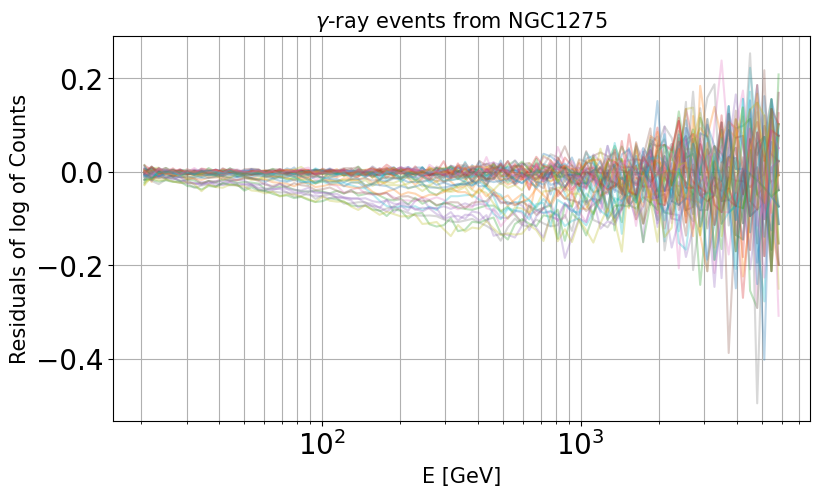

In [44]:
name = 'flare0_agnostic'

A = priors[name]['A']

samples = priors[name]['samples_onespect']

A.configure_plot(xmin=None, xmax=None, ymin=None,ymax=None,legend=0, logx=1, logy=0)
# A.configure_plot(xmin=2e1, xmax=1e3, ymin=-0.05,ymax=0.05,legend=0, logx=1, logy=0)
for i in range(min(len(samples),50)):
    A.configure_model(params=samples[i]['params'])
    A.import_counts(obs=samples[i]['data'],exp=samples[i]['exp'])
    new_fig = 1 if i==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=None,color_obs=None,linestyle="-",
                   label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=0, transparency=0.7)

# observations = [samples[0]]

# for i,obs in enumerate(observations):
#     A.configure_model(params=obs['params'])
#     A.import_counts(obs=obs['data'],exp=obs['exp'])
#     A.compute_case(new_fig=0,new_counts=0,color='k',color_obs=colors[i],linestyle_obs="-",label_exp=0,label_obs=0,
#                    errorbands=0, errors=0, plot_exp=0)
#     A.compute_case(new_fig=0,new_counts=0,color=colors[i],color_obs=colors[i],linestyle=":",label_exp=0,label_obs=0,
#                         errorbands=0, errors=0, plot_obs=0) 

In [38]:
def prepare_logratios(name, data):
    logratios = []
    for spectrum in data:
        lrs = trainer.infer(
            priors[name]['net'],
            spectrum,
            priors[name]['samples_prior'],
        )
        logratios.append(lrs)
    return logratios

def plot_posteriors(name,logratios,data,figsize=None, axes=None, colors_truth='r',POIs=[0,1]):
    fig = None
    if axes is None:
        if figsize is None: figsize = (12,12/len(logratios))
        fig = plt.figure(figsize=figsize)
        for j in range(len(logratios)): fig.add_subplot(1,len(logratios),j+1)
        axes = fig.axes
    A = priors[name]['A']
    if not isinstance(colors_truth,list):
        one_color = copy.copy(colors_truth)
        colors_truth = [one_color]*len(logratios)
    for j in range(len(logratios)):
        swyft.plot.plot._plot_2d(
            logratios[j],
            A.param_names[POIs[0]],
            A.param_names[POIs[1]],
            color='k',
            color_truth=colors_truth[j],
            smooth=3,
            truth={A.param_names[i]:data[j]['params'][i] for i in POIs},
            ax = axes[j]
        )
    return fig
    

/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/gertwk/.conda/envs/swyft4-dev-notebook/lib/pyt ...
  rank_zero_warn(
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/pytorch_lightning/loops/epoch/prediction_epoch_loop.py:173: UserWarning: Lightning couldn't infer the indices fetched for your dataloader.
  warning_cache.warn("Lightning couldn't infer the indices fetched for your dataloader.")
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

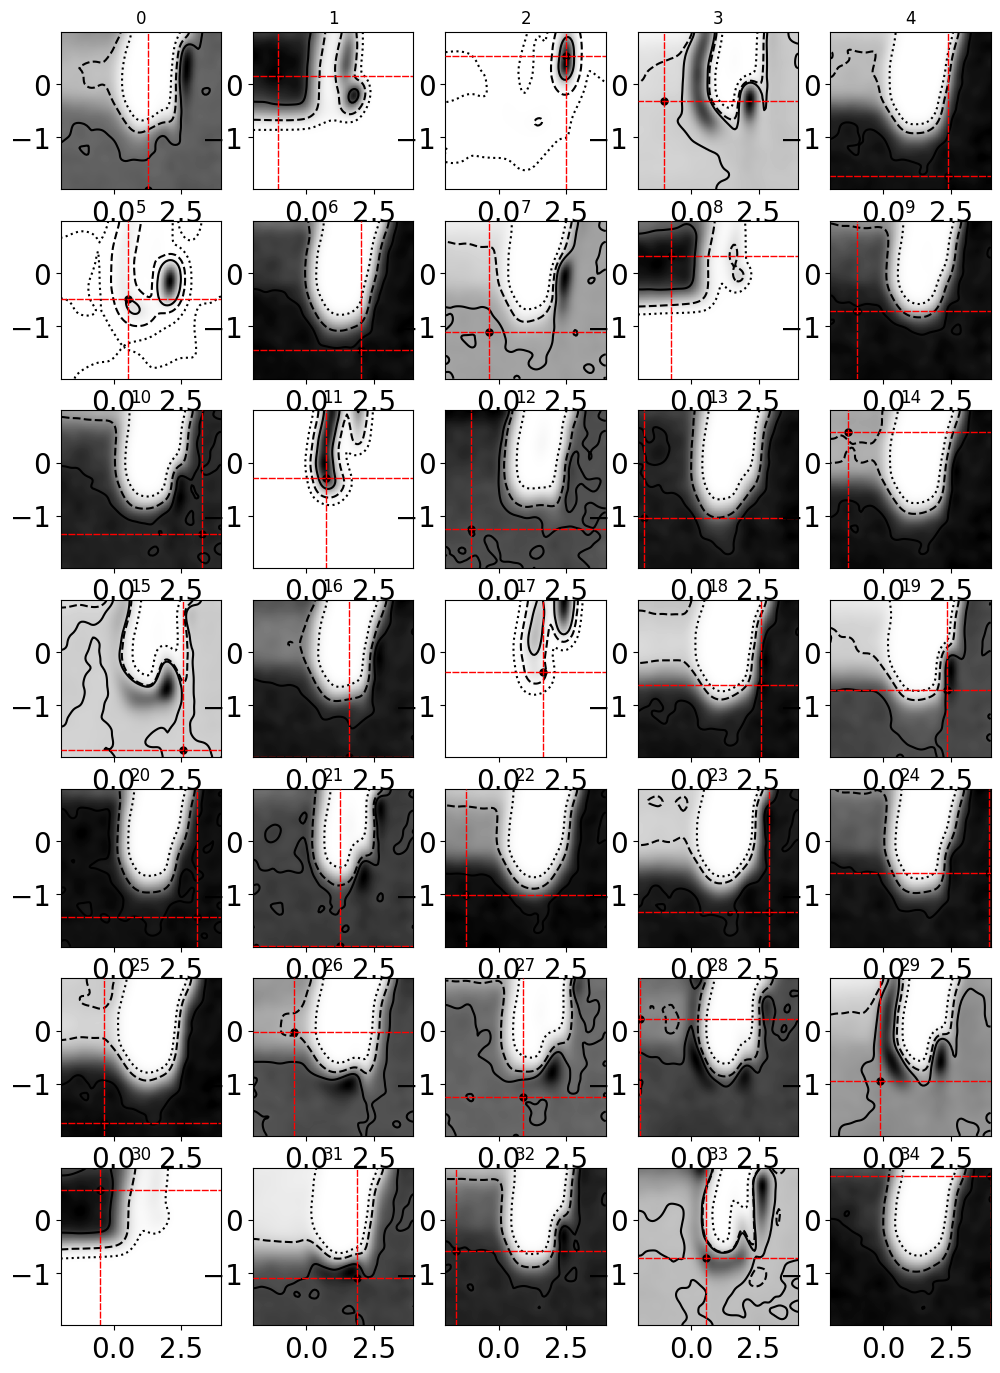

In [11]:
name = 'flare0_confident1'
n = 35
data = [priors[name]['samples_explim'][i] for i in range(n)]

fig = plt.figure(figsize=(12,(12/5)*np.ceil(n/5)))
for i in range(n): 
    fig.add_subplot(int(np.ceil(n/5)),5,i+1)
    fig.axes[-1].set_title(str(i))

logratios = prepare_logratios(name,data)
fig = plot_posteriors(name, logratios, data, axes = fig.axes)

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

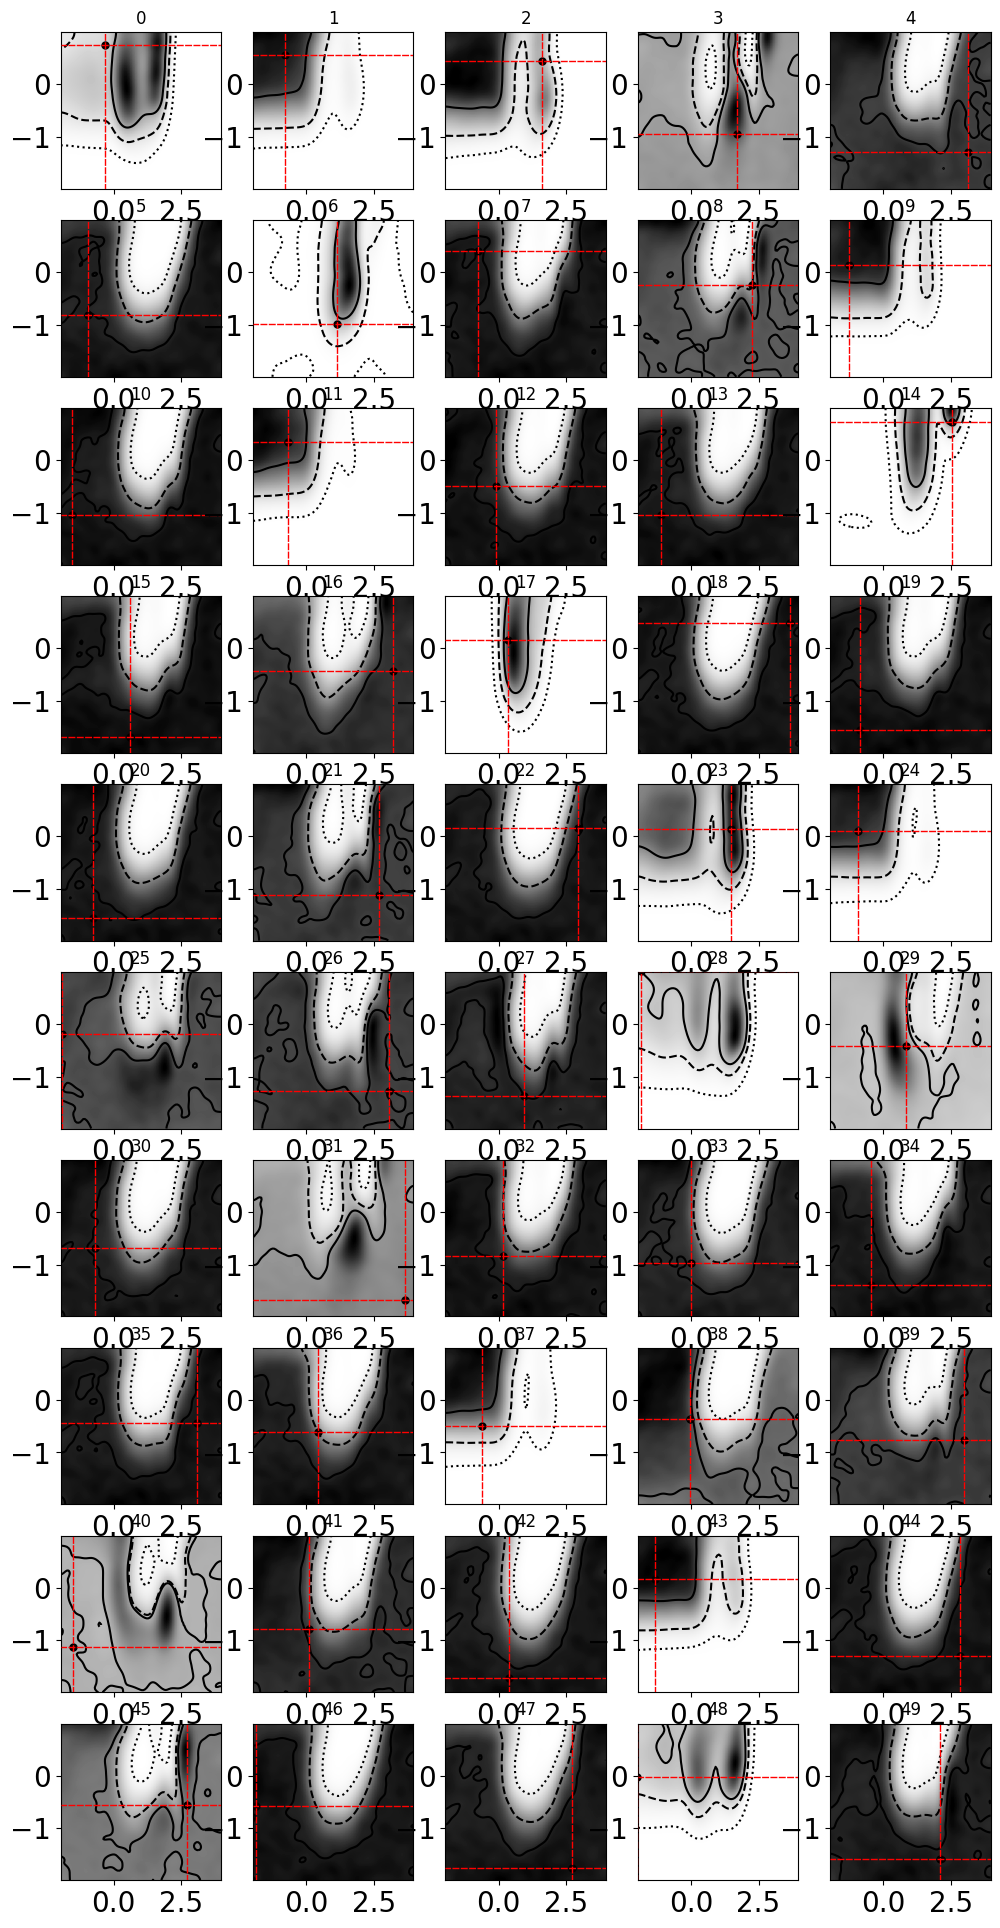

In [42]:
name = 'flare0_informed'
n = 50
data = [priors[name]['samples_onespect'][i] for i in range(n)]

fig = plt.figure(figsize=(12,(12/5)*np.ceil(n/5)))
for i in range(n): 
    fig.add_subplot(int(np.ceil(n/5)),5,i+1)
    fig.axes[-1].set_title(str(i))

logratios = prepare_logratios(name,data)
fig = plot_posteriors(name, logratios, data, axes = fig.axes)

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

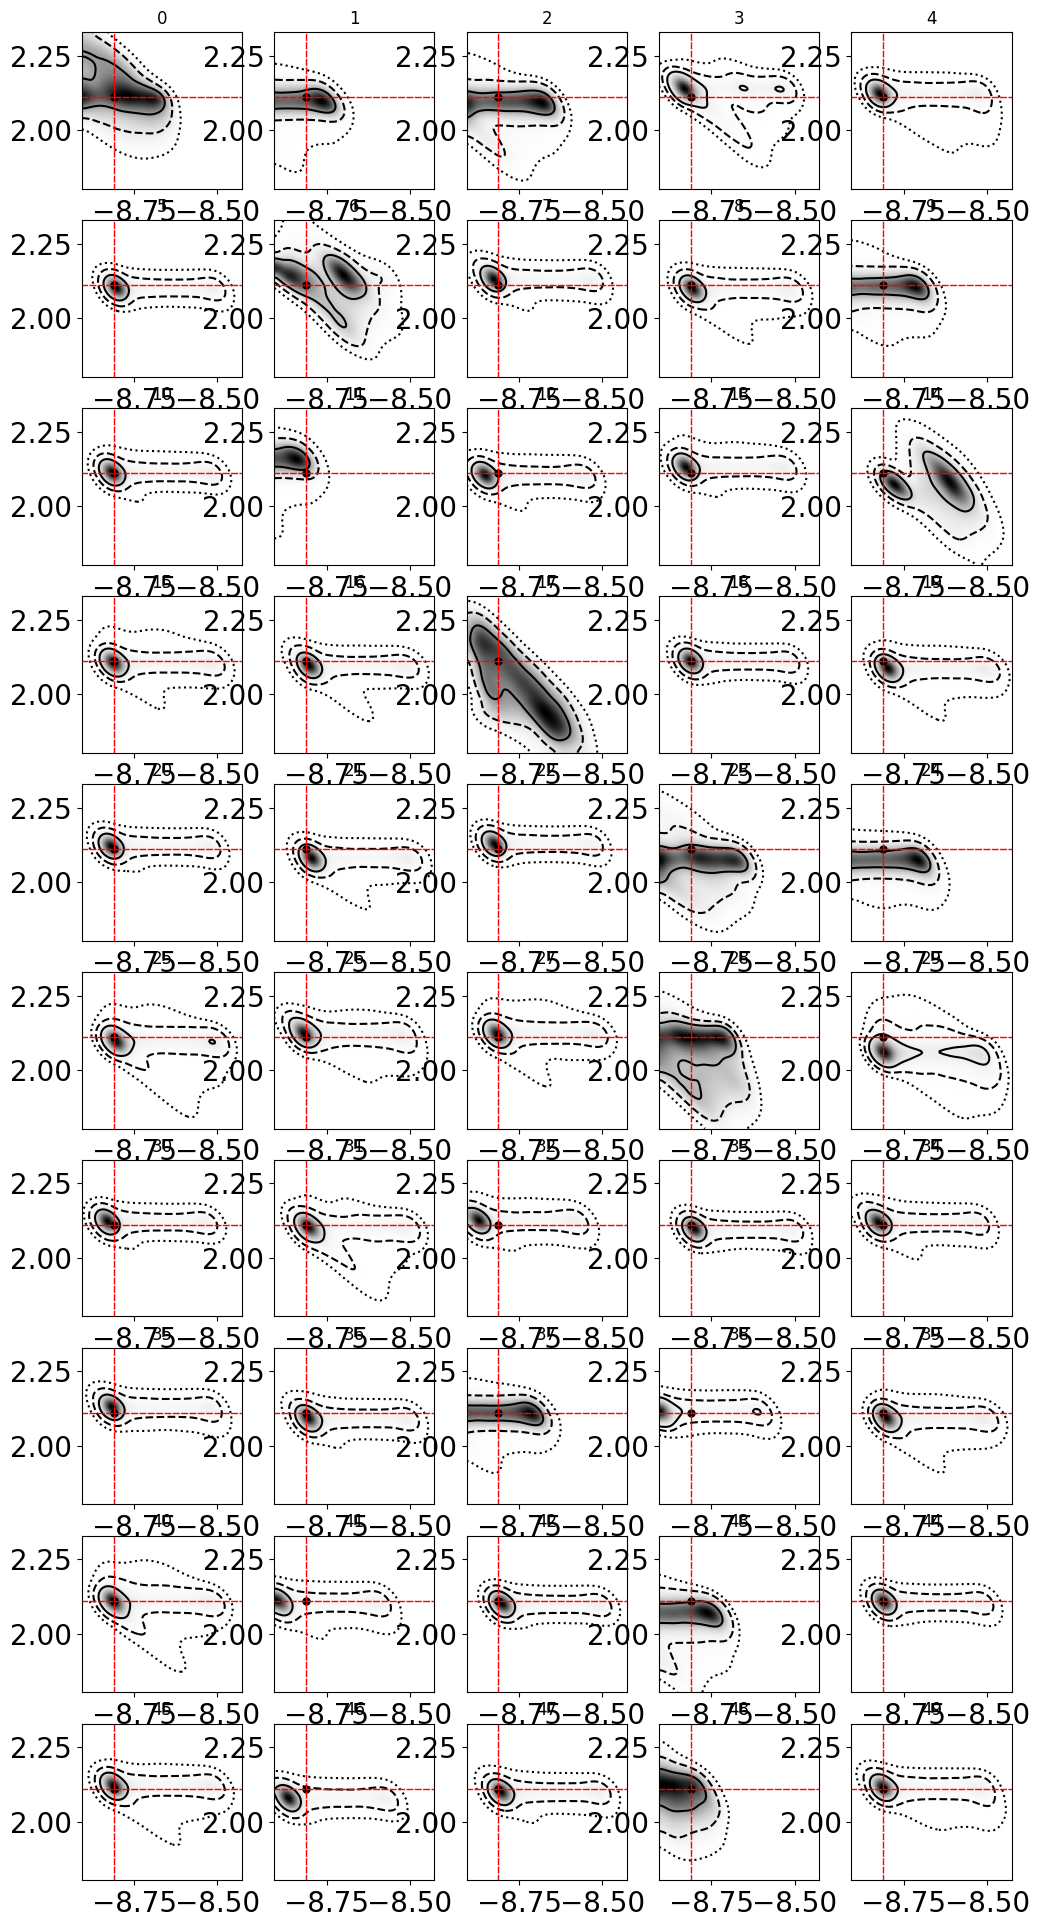

In [43]:
name = 'flare0_informed'
n = 50
data = [priors[name]['samples_onespect'][i] for i in range(n)]

fig = plt.figure(figsize=(12,(12/5)*np.ceil(n/5)))
for i in range(n): 
    fig.add_subplot(int(np.ceil(n/5)),5,i+1)
    fig.axes[-1].set_title(str(i))

logratios = prepare_logratios(name,data)
fig = plot_posteriors(name, logratios, data, axes = fig.axes, POIs=[2,3])

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

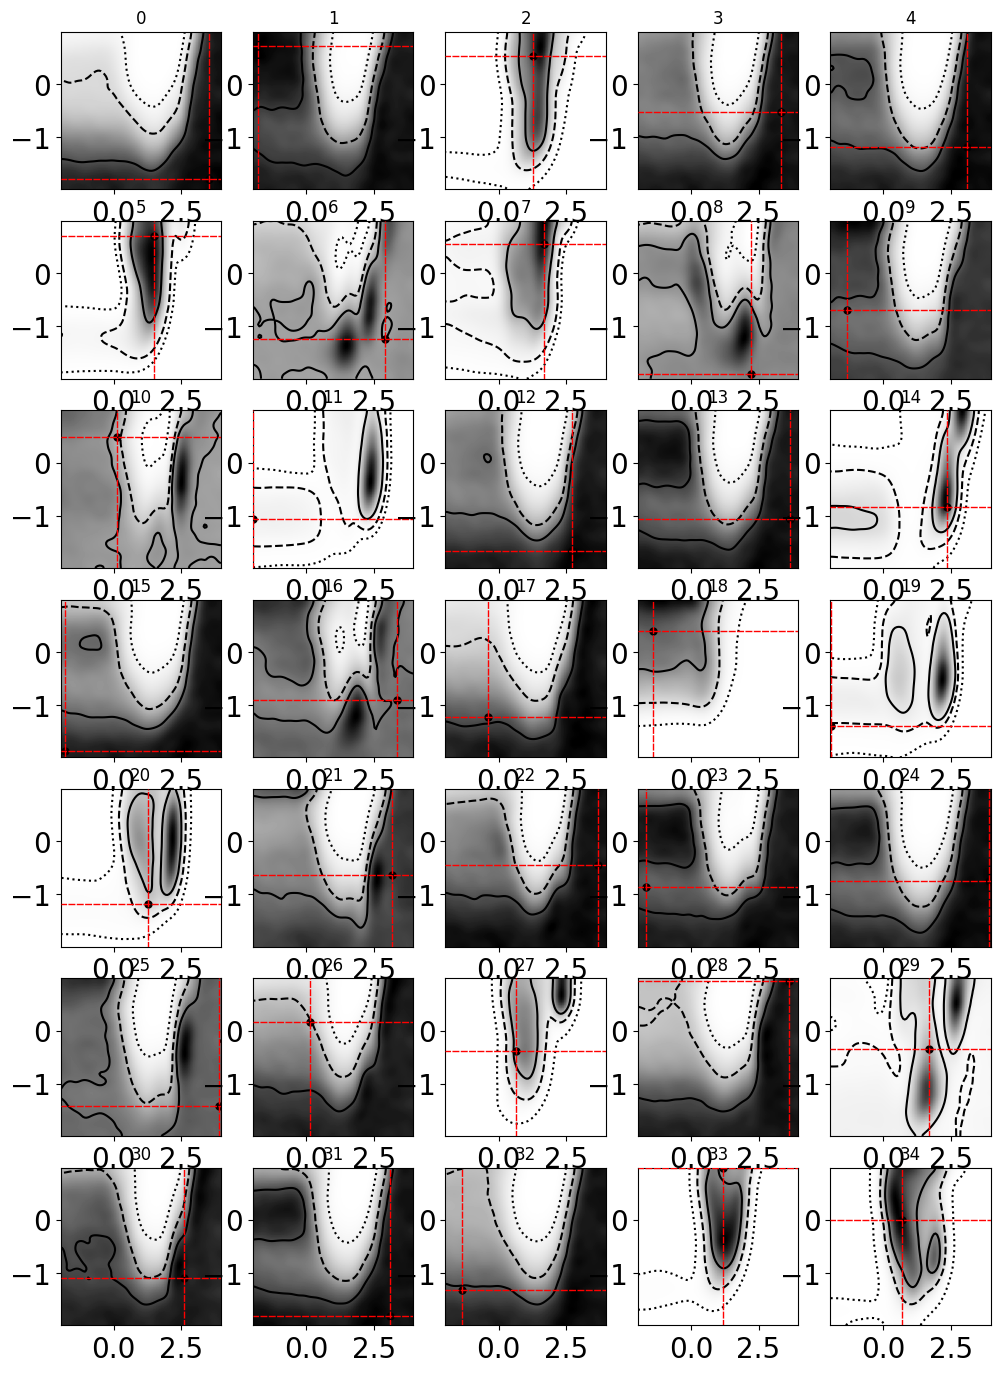

In [66]:
name = 'flare0_semi_informed'
n = 35
data = [priors[name]['samples_explim'][i] for i in range(n)]

fig = plt.figure(figsize=(12,(12/5)*np.ceil(n/5)))
for i in range(n): 
    fig.add_subplot(int(np.ceil(n/5)),5,i+1)
    fig.axes[-1].set_title(str(i))

logratios = prepare_logratios(name,data)
fig = plot_posteriors(name, logratios, data, axes = fig.axes)


/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/gertwk/.conda/envs/swyft4-dev-notebook/lib/pyt ...
  rank_zero_warn(
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

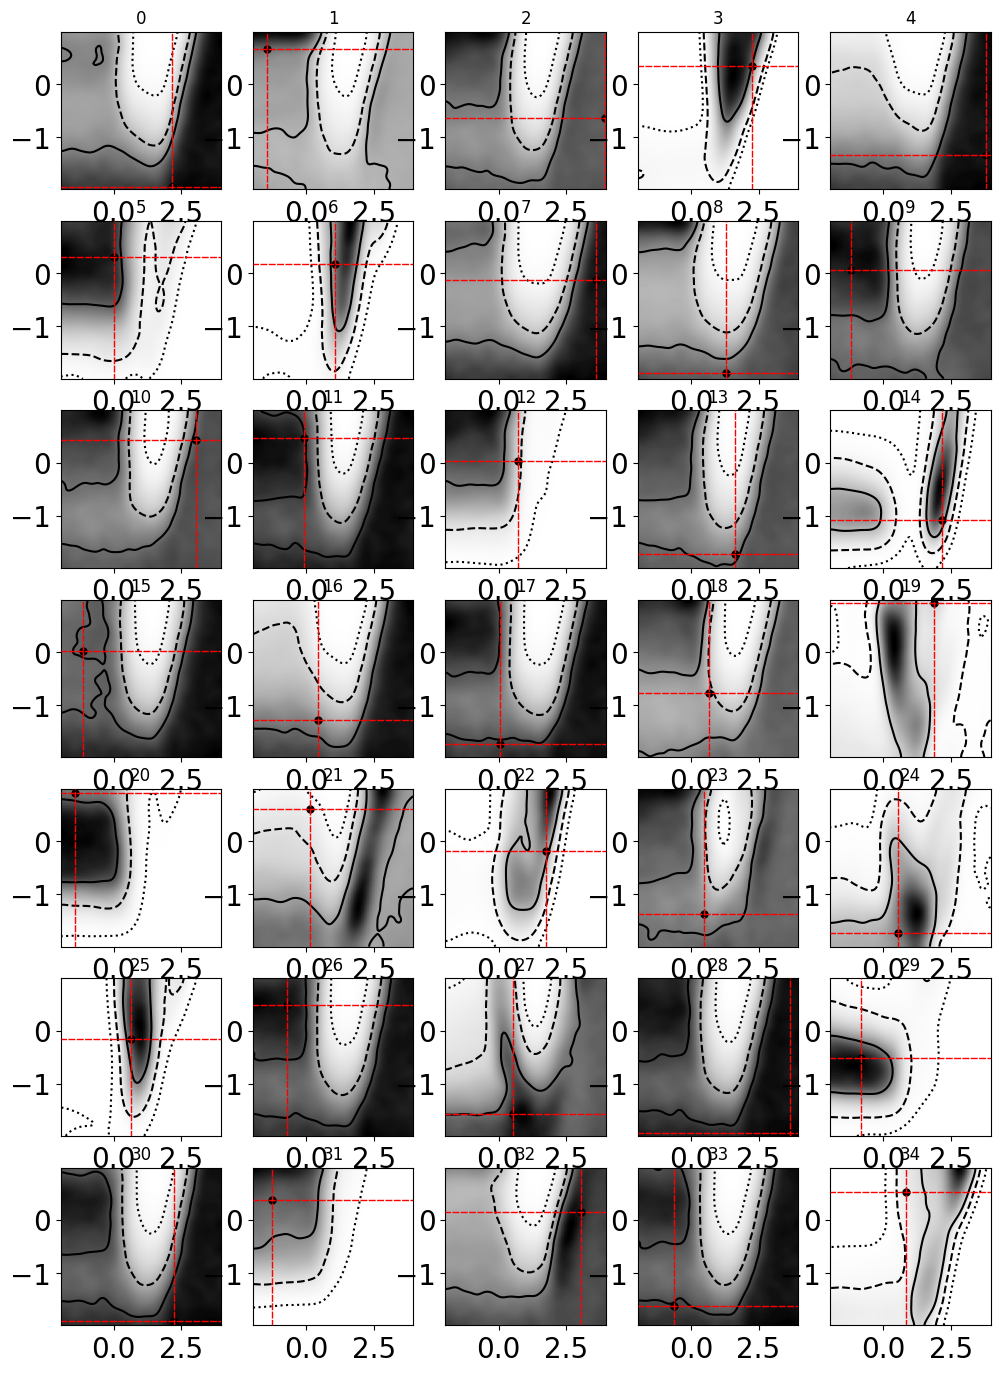

In [69]:
name = 'flare0_agnostic'
n = 35
data = [priors[name]['samples_explim'][i] for i in range(n)]

fig = plt.figure(figsize=(12,(12/5)*np.ceil(n/5)))
for i in range(n): 
    fig.add_subplot(int(np.ceil(n/5)),5,i+1)
    fig.axes[-1].set_title(str(i))

logratios = prepare_logratios(name,data)
fig = plot_posteriors(name, logratios, data, axes = fig.axes)


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

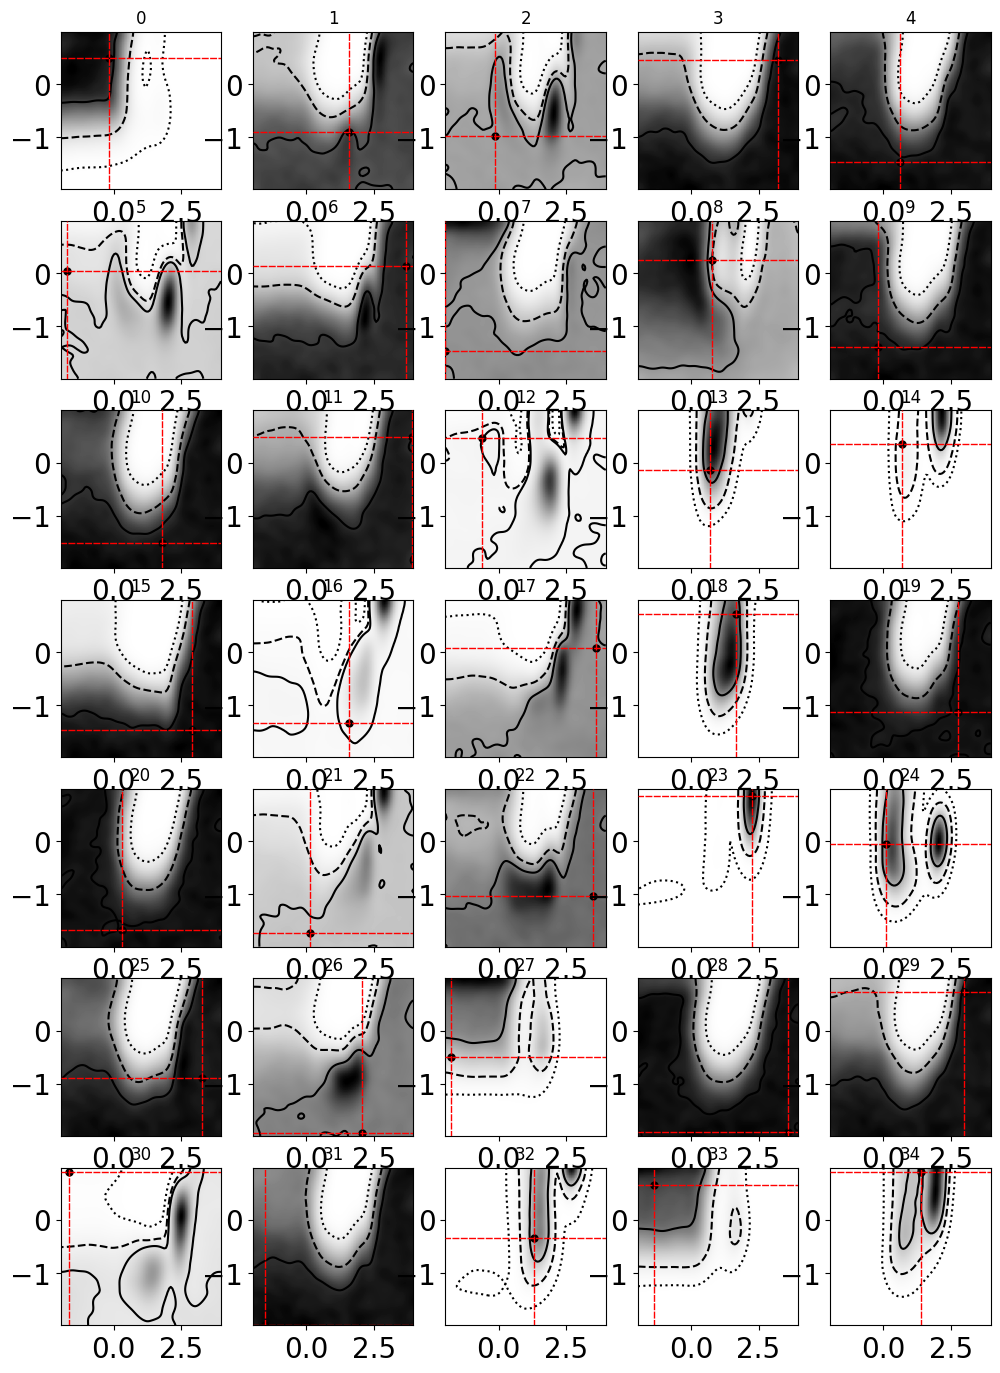

In [70]:
name = 'flare0_informed'
n = 35
data = [priors[name]['samples_explim'][i] for i in range(n)]

fig = plt.figure(figsize=(12,(12/5)*np.ceil(n/5)))
for i in range(n): 
    fig.add_subplot(int(np.ceil(n/5)),5,i+1)
    fig.axes[-1].set_title(str(i))

logratios = prepare_logratios(name,data)
fig = plot_posteriors(name, logratios, data, axes = fig.axes)

In [ ]:
name = 'flare0_informed'
n = 0
orig_data = copy.copy(priors[name]['samples_explim'][n])
orig_params = orig_data['params'].copy()
ms = [-1.5, 0.5, 0.8, 1.1, 1.5, 2, 2.5, 2.9]
gs = [orig_params[1], -0.5, -1]
ags = []
for g in gs:
    for m in ms:
        ags.append([m,g])
data = []
A = priors[name]['A']
A.configure_model(ALP_seed=0, noise='gauss',sigma=0)
for ag in ags:
    new_params = orig_params
    new_params[0] = ag[0]
    new_params[1] = ag[1]
    sim_bounds = np.array([new_params, new_params]).T
    sim = ALP_SWYFT_Simulator(A, sim_bounds, priors[name]['prior_funcs'])
    new_data = sim.sample(1)[0]
    new_data['data'] = new_data['exp']
    data.append(new_data)
logratios = prepare_logratios(name,data)

colors_data=['r']*len(data)
for i in range(len(colors_data)):
    if i in [7,8,13]: 
        colors_data[i] = 'm'
    elif i in [9]: 
        colors_data[i] = 'b'
    elif i in [2,3,5,10,11,12]:
        colors_data[i] = 'g'
    elif i in [0,1]:
        colors_data[i] = 'c'
    elif i in [4,6]:
        colors_data[i] = 'y'
        

dim = len(ms)
fig = plt.figure(figsize=(12,(12/dim)*np.ceil(len(data)/dim)))
for i in range(len(data)): 
    fig.add_subplot(int(np.ceil(len(data)/dim)),dim,i+1)
    # fig.axes[-1].set_title(str(i))
    if i <= (len(gs)-1)*(dim)-1:
        fig.axes[-1].set_xticks([])
    else:
        fig.axes[-1].set_xticks([ms[i-(len(gs)-1)*(dim)]])
    if i%dim != 0:
        fig.axes[-1].set_yticks([])
    else:
        fig.axes[-1].set_yticks([gs[int(i/dim)]])
fig.supxlabel(xlabel)
fig.supylabel(ylabel)


fig = plot_posteriors(name, logratios, data, axes = fig.axes, colors_truth = colors_data)

fig_specs = plt.figure(figsize=(12,12))

fig_specs.add_subplot(3,1,1)
A.configure_plot(xmin=2e1, xmax=6e3, ymin=None,ymax=None,legend=0, logx=1, logy=0)
for i,j in enumerate([7,8,13,14,15,16,17,18,19,20,21,22,23]):
    A.configure_model(params=data[j]['params'])
    A.import_counts(obs=data[j]['data'],exp=data[j]['exp'])
    new_fig = 1 if i==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=colors_data[j],color_obs=colors_data[j],linestyle="-", axes=fig_specs.axes[-1],
                   label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=0, transparency=0.7)
fig_specs.axes[-1].set_title('Spectra leading to exclusions')
fig_specs.axes[-1].set_xlabel('')
fig_specs.axes[-1].set_xticks([])
fig_specs.axes[-1].set_ylabel('')

fig_specs.add_subplot(3,1,2)
for i,j in enumerate([3,4,5,6,9,10,11,12]):
    A.configure_model(params=data[j]['params'])
    A.import_counts(obs=data[j]['data'],exp=data[j]['exp'])
    new_fig = 1 if i==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=colors_data[j],color_obs=colors_data[j],linestyle="-", axes=fig_specs.axes[-1],
                   label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=0, transparency=0.7)
fig_specs.axes[-1].set_title('Spectra leading to detections')
fig_specs.axes[-1].set_xlabel('')
fig_specs.axes[-1].set_xticks([])
fig_specs.axes[-1].set_ylabel('')

fig_specs.add_subplot(3,1,3)
for i,j in enumerate([0,1]):
    A.configure_model(params=data[j]['params'])
    A.import_counts(obs=data[j]['data'],exp=data[j]['exp'])
    new_fig = 1 if i==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=colors_data[j],color_obs=colors_data[j],linestyle="-", axes=fig_specs.axes[-1],
                   label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=0, transparency=0.7)
no_alp_params = copy.copy(orig_params)
no_alp_params[0] = -6
no_alp_params[1] = -6
amp_linestyles = ['--','-.',':']
for i,amp in enumerate([orig_params[2], -8.9,-9]):
    no_alp_params[2] = amp
    A.configure_model(params=no_alp_params)
    new_fig = 1 if i==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=1,color=colors_data[j],color_obs='k',linestyle_obs=amp_linestyles[i], axes=fig_specs.axes[-1],
                       label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=0, transparency=0.7)
fig_specs.axes[-1].set_title('Spectra leading to false detections due to truncated bounds')
fig_specs.axes[-1].set_ylabel('')


fig_specs.supylabel('Residuals of log of Counts', fontsize=18)
fig_specs.tight_layout()

In [ ]:
name = 'flare0_informed'
n = 0
orig_data = copy.copy(priors[name]['samples_explim'][n])
orig_params = orig_data['params'].copy()
ms = [-1.5, 0.5, 0.8, 1.1, 1.5, 2, 2.5, 2.9]
gs = [orig_params[1], -0.5, -1]
ags = []
for g in gs:
    for m in ms:
        ags.append([m,g])
# data = []
# A = priors[name]['A']
# A.configure_model(ALP_seed=0, noise='gauss',sigma=0)
# for ag in ags:
#     new_params = orig_params
#     new_params[0] = ag[0]
#     new_params[1] = ag[1]
#     sim_bounds = np.array([new_params, new_params]).T
#     sim = ALP_SWYFT_Simulator(A, sim_bounds, priors[name]['prior_funcs'])
#     new_data = sim.sample(1)[0]
#     new_data['data'] = new_data['exp']
#     data.append(new_data)
# logratios = prepare_logratios(name,data)

colors_data=['r']*len(data)
for i in range(len(colors_data)):
    if i in [7,8,13]: 
        colors_data[i] = 'm'
    elif i in [9]: 
        colors_data[i] = 'b'
    elif i in [2,3,5,10,11,12]:
        colors_data[i] = 'g'
    elif i in [0,1]:
        colors_data[i] = 'c'
    elif i in [4,6]:
        colors_data[i] = 'y'
        

dim = len(ms)
fig = plt.figure(figsize=(12,(12/dim)*np.ceil(len(data)/dim)))
for i in range(len(data)): 
    fig.add_subplot(int(np.ceil(len(data)/dim)),dim,i+1)
    # fig.axes[-1].set_title(str(i))
    if i <= (len(gs)-1)*(dim)-1:
        fig.axes[-1].set_xticks([])
    else:
        fig.axes[-1].set_xticks([ms[i-(len(gs)-1)*(dim)]])
    if i%dim != 0:
        fig.axes[-1].set_yticks([])
    else:
        fig.axes[-1].set_yticks([gs[int(i/dim)]])
fig.supxlabel(xlabel)
fig.supylabel(ylabel)


fig = plot_posteriors(name, logratios, data, axes = fig.axes, colors_truth = colors_data,POIs=[2,3])

fig_specs = plt.figure(figsize=(12,12))

fig_specs.add_subplot(3,1,1)
A.configure_plot(xmin=2e1, xmax=6e3, ymin=None,ymax=None,legend=0, logx=1, logy=0)
for i,j in enumerate([7,8,13,14,15,16,17,18,19,20,21,22,23]):
    A.configure_model(params=data[j]['params'])
    A.import_counts(obs=data[j]['data'],exp=data[j]['exp'])
    new_fig = 1 if i==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=colors_data[j],color_obs=colors_data[j],linestyle="-", axes=fig_specs.axes[-1],
                   label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=0, transparency=0.7)
fig_specs.axes[-1].set_title('Spectra leading to exclusions')
fig_specs.axes[-1].set_xlabel('')
fig_specs.axes[-1].set_xticks([])
fig_specs.axes[-1].set_ylabel('')

fig_specs.add_subplot(3,1,2)
for i,j in enumerate([3,4,5,6,9,10,11,12]):
    A.configure_model(params=data[j]['params'])
    A.import_counts(obs=data[j]['data'],exp=data[j]['exp'])
    new_fig = 1 if i==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=colors_data[j],color_obs=colors_data[j],linestyle="-", axes=fig_specs.axes[-1],
                   label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=0, transparency=0.7)
fig_specs.axes[-1].set_title('Spectra leading to detections')
fig_specs.axes[-1].set_xlabel('')
fig_specs.axes[-1].set_xticks([])
fig_specs.axes[-1].set_ylabel('')

fig_specs.add_subplot(3,1,3)
for i,j in enumerate([0,1]):
    A.configure_model(params=data[j]['params'])
    A.import_counts(obs=data[j]['data'],exp=data[j]['exp'])
    new_fig = 1 if i==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=colors_data[j],color_obs=colors_data[j],linestyle="-", axes=fig_specs.axes[-1],
                   label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=0, transparency=0.7)
no_alp_params = copy.copy(orig_params)
no_alp_params[0] = -6
no_alp_params[1] = -6
amp_linestyles = ['--','-.',':']
for i,amp in enumerate([orig_params[2], -8.9,-9]):
    no_alp_params[2] = amp
    A.configure_model(params=no_alp_params)
    new_fig = 1 if i==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=1,color=colors_data[j],color_obs='k',linestyle_obs=amp_linestyles[i], axes=fig_specs.axes[-1],
                       label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=0, transparency=0.7)
fig_specs.axes[-1].set_title('Spectra leading to false detections due to truncated bounds')
fig_specs.axes[-1].set_ylabel('')


fig_specs.supylabel('Residuals of log of Counts', fontsize=18)
fig_specs.tight_layout()